![Py4Eng](../logo.png)

# Density Estimation with Normalizing Flows
## Yoav Ram

In this session we will understand:
- what density estimation is, and why it is harder than it looks
- how the classical baselines -- kernel density estimation and Gaussian mixtures -- work, and where they break down
- how a normalizing flow turns a simple base distribution into a complicated one through an invertible map
- how to train a masked autoregressive flow with FlowJAX and read its log-likelihood
- how the three model families compare on a toy 2D dataset and on a real six-dimensional benchmark

This is the one session that uses [FlowJAX](https://danielward27.github.io/flowjax/) and [Equinox](https://github.com/patrick-kidger/equinox/) rather than Keras.
There is no Keras normalizing-flow implementation worth teaching, and flows are built out of invertible bijections rather than layers, so the API looks different on purpose.
Both libraries are built on JAX, so everything here runs on the same accelerator as the rest of the course.


Density estimation asks for a model of an unknown distribution $p(x)$ given only samples from it.
Unlike classification or regression there is no label to predict -- the density *is* the answer.

We work through two datasets:

1. **`make_moons`**, a 2D toy: fit KDE and a GMM, see why they struggle with curved support, then train a masked autoregressive flow (MAF) and compare densities and samples.
2. **UCI POWER**, a six-dimensional benchmark: fit the same four models and compare test log-likelihoods in nats.


In [33]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

import jax
import jax.numpy as jnp
from jax import random
import flowjax
import flowjax.bijections
import flowjax.distributions
import flowjax.flows
import flowjax.train

sns.set(style='white', context='talk')
SEED = 130
print('JAX:', jax.__version__, 'backend:', jax.default_backend())
print('FlowJAX:', flowjax.__version__, 'Equinox:', __import__('equinox').__version__)

JAX: 0.9.2 backend: cpu
FlowJAX: 19.1.0 Equinox: 0.13.7


In [49]:
# Some utility functions for plotting and data manipulation
def make_grid(data, pad=0.6, n=220):
    lower = data.min(axis=0) - pad
    upper = data.max(axis=0) + pad
    xs = np.linspace(lower[0], upper[0], n)
    ys = np.linspace(lower[1], upper[1], n)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)
    return xs, ys, grid, lower, upper

def plot_density(xs, ys, log_density, data=None, title="", cmap="viridis", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    density = np.exp(np.asarray(log_density)).reshape(len(ys), len(xs))
    ax.contourf(xs, ys, density, levels=30, cmap=cmap)
    ax.set_title(title)
    if data is not None:
        ax.scatter(data[:, 0], data[:, 1], s=4, c="white", alpha=0.18, edgecolors="none")

def plot_samples(samples, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.scatter(samples[:, 0], samples[:, 1], s=6, c="black", alpha=0.5, edgecolors="none")
    ax.set_title(title)

def clip_to_window(samples, lower, upper):
    mask = np.all((samples >= lower) & (samples <= upper), axis=1)
    return samples[mask]



## Two-moons dataset

The two-moons dataset is useful because the true distribution is clearly non-Gaussian and lies on a curved manifold.
That makes it a good stress test for density models with different inductive biases.


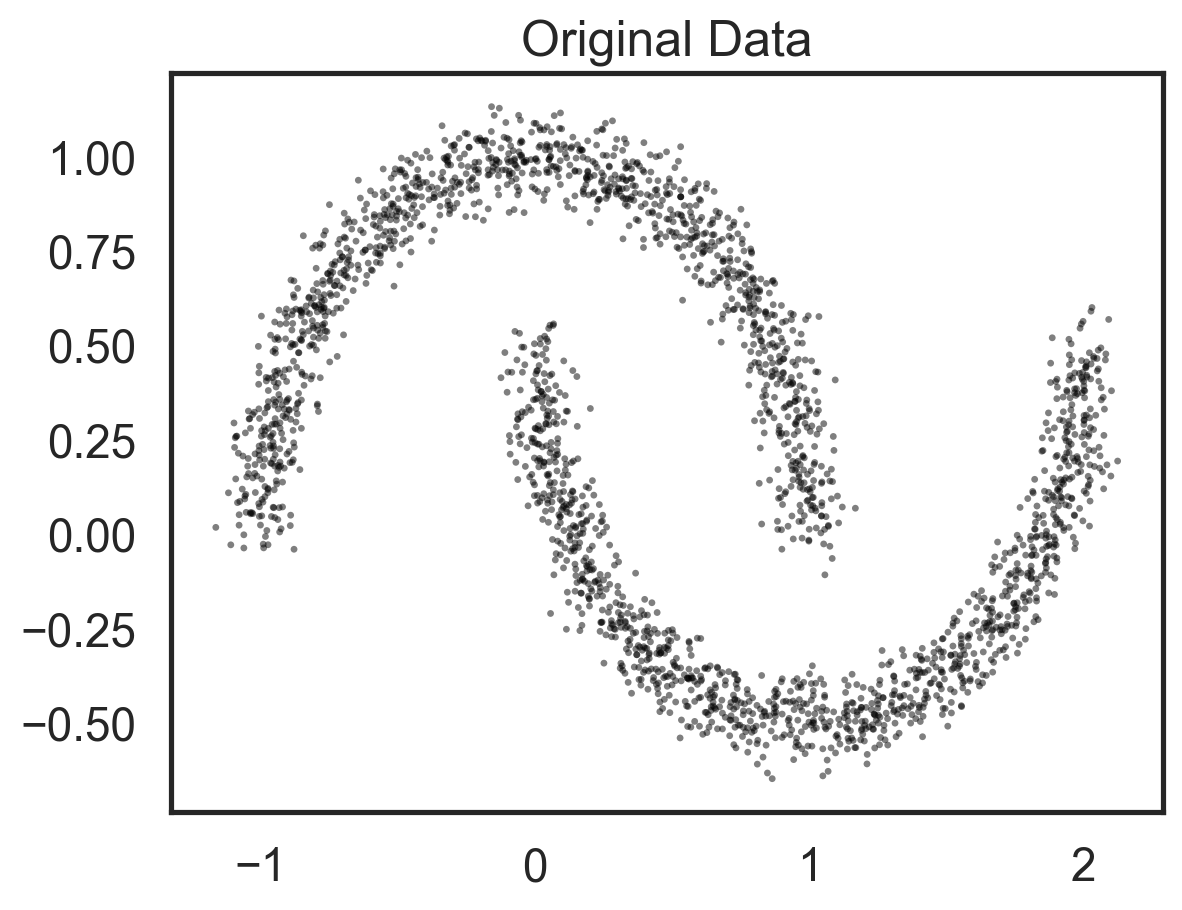

In [46]:

X, labels = make_moons(n_samples=2500, noise=0.06, random_state=0)
X = X.astype(np.float32)
xs, ys, grid, lower, upper = make_grid(X)

plot_samples(X, title="Original Data")


## Compact Baselines: KDE and GMM

We keep two classical baselines:

1. **KDE** is flexible and local, but its smoothness is controlled by a bandwidth parameter.
2. **GMM** is parametric and easy to sample from, but it prefers elliptic clusters.

Both models are useful reference points before we train a flow model.

### KDE 
In Kernel density estimation, we put one Gaussian of a specific width (hyper parameter) over each data point, and then sum the Gaussians together to get the full density estimate.


In [50]:
kde = KernelDensity(kernel="gaussian", bandwidth=0.18)
kde.fit(X)
kde_log_density = kde.score_samples(grid)
kde_samples = kde.sample(1000)

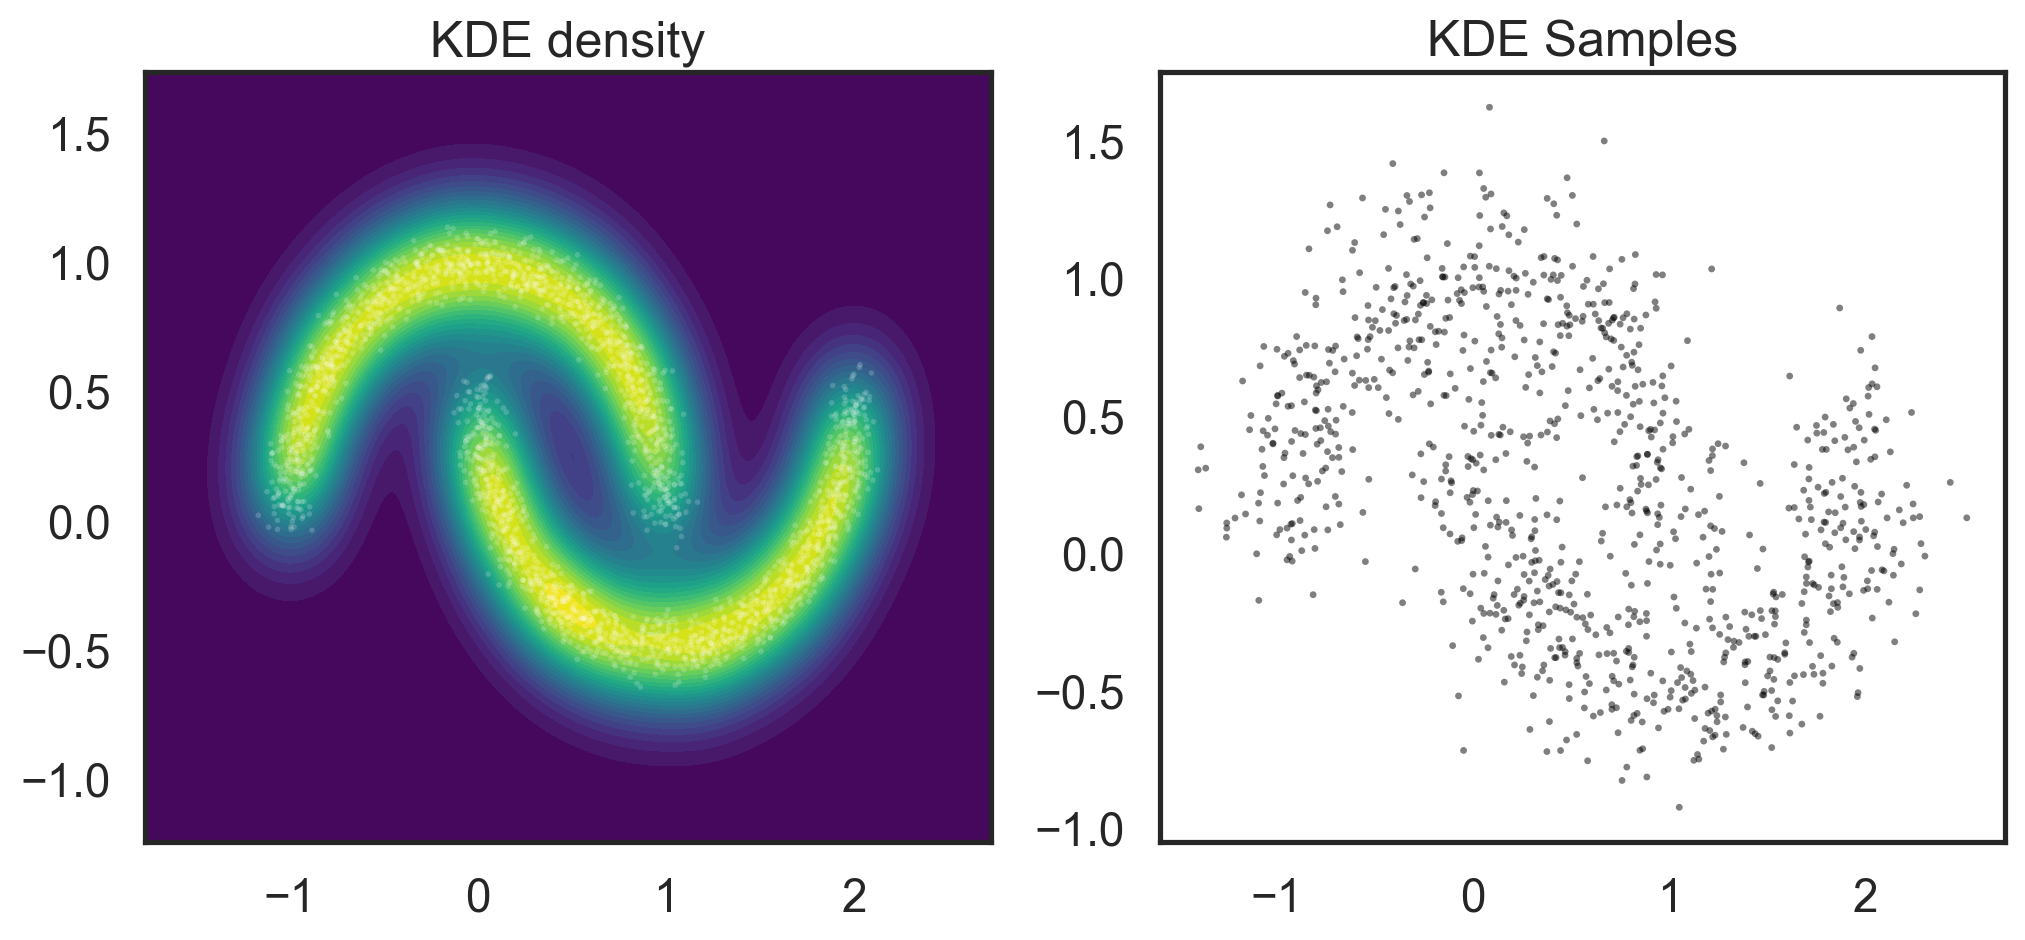

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_density(xs, ys, kde_log_density, data=X, title="KDE density", ax=ax[0])
plot_samples(kde_samples, title="KDE Samples", ax=ax[1])


### Gaussian mixed models

In GMM, we assume a mixture model (a type of a hierarchical model), here shown for a mixture of two Gaussians:
$$
x_i \sim \begin{cases}
    N(\mu_1, \rho_1), & z_i=0 \\
    N(\mu_2, \rho_2), & z_i=1 \\
\end{cases}
$$
where $z_i$ is a latent random variable that controls the mixture:
$$
z_i \sim \mathit{Bernoulli}(p)
$$
That is, $x_i$ is distributed according to $N(\mu_1, \rho_1)$ with probability $p$ and according to $N(\mu_2, \rho_2)$ with probability $1-p$.

In [52]:
gmm = GaussianMixture(n_components=8, covariance_type="full", random_state=0)
gmm.fit(X)
gmm_log_density = gmm.score_samples(grid)
gmm_samples = gmm.sample(1000)[0]

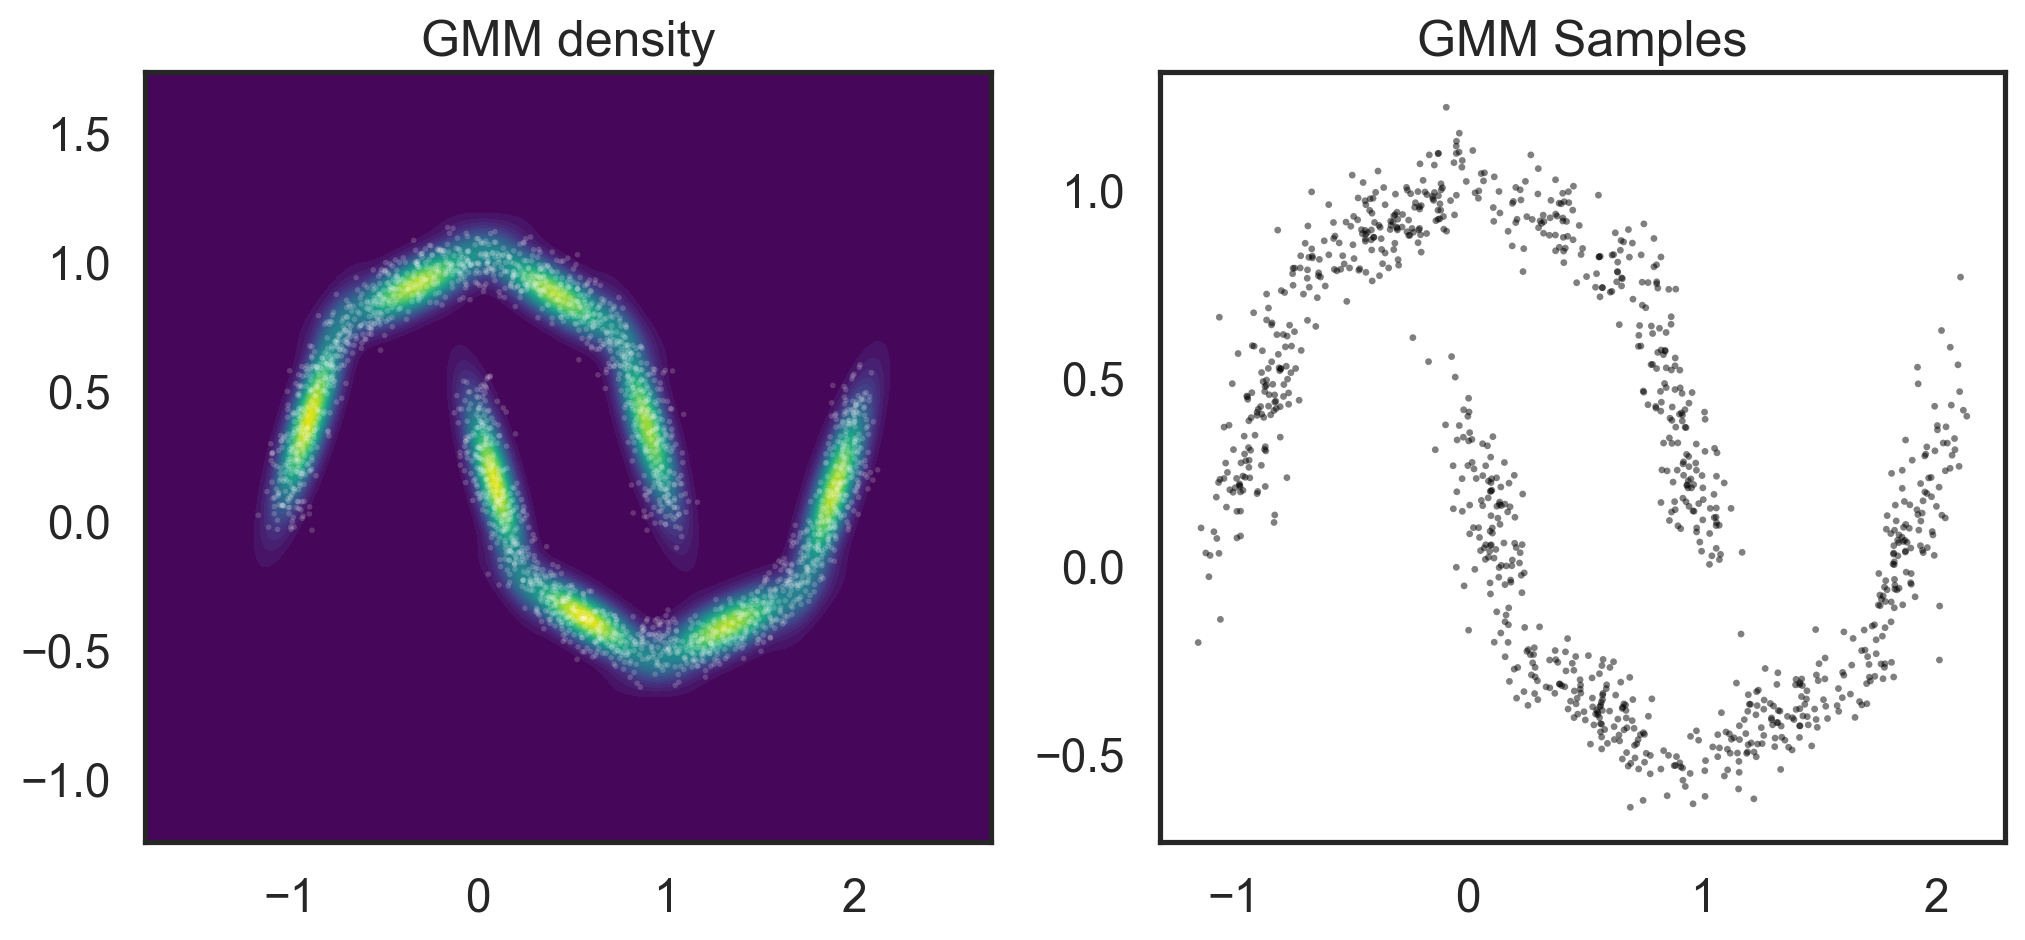

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_density(xs, ys, gmm_log_density, data=X, title="GMM density", ax=ax[0])
plot_samples(gmm_samples, title="GMM Samples", ax=ax[1])


The KDE tracks the moons reasonably well, but has no global latent representation and can oversmooth or leak mass between nearby regions.

The GMM is efficient and interpretable, but a small number of Gaussian components cannot bend naturally around the two crescents.

This is the point where normalizing flows become interesting: they keep **sampling** and **density evaluation**, but with a much more flexible geometry.


## Normalizing Flows

A normalizing flow is built from two pieces that play very different roles, and it's worth keeping them separate in your head:

- The base distribution $p_Z$: a fixed, simple distribution we can sample from and evaluate exactly, in many cases a standard multivariate Gaussian, 
$$
z_i \sim \mathcal{N}(0, I)
$$
- The map $f_{\theta}$ — a learned (with parameters $\theta$), *invertible* function that warps $z$ into the data space,
$$
x_i = f_{\theta}(z_i) \\
z_i = f_{\theta}^{-1}(x_i)
$$

$p_Z$ never changes; all of the flexibility needed to fit a complicated, curved data density is in $f$.

Because $f_{\theta}$ is invertible, we can both sample $x$:
$$
z_i \sim \mathcal{N}(0, I) \\ 
x_i = f_{\theta}(z_i)
$$
as well as evaluate exact density using the [change-of-variables formula](https://en.wikipedia.org/wiki/Probability_density_function#Vector_to_vector):
$$
p_X(x_i \mid \theta) = p_Z(f_{\theta}^{-1}(x_i)) \cdot \left|\det J_{f_{\theta}^{-1}}(x_i)\right|
$$

So designing a flow means designing $f_{\theta}$: it has to be 
1. expressive enough to capture the data, 
1. invertible, and 
1. have a Jacobian determinant that's cheap to compute.

Here we use a [*masked autoregressive flow* (MAF)](http://arxiv.org/abs/1705.07057) with rational quadratic spline transformations as to build $f$ — two independent design choices that combine:

- MAF is the *structure* of $f$: it's a stack of autoregressive layers, where each output dimension $x_{i,j}$ is transformed using only $z_{i,1:j}$. This masking makes $f$ invertible by construction and makes $J_{f^{-1}}$ triangular, so its determinant is just the product of its diagonal — cheap to compute regardless of dimensionality.
- Rational quadratic splines are the *transformation*: the actual per-dimension function each autoregressive layer applies. The original MAF paper used simple affine transformers ($x_{i,j} = a_j z_{i,j} + b_j$); splines are a more flexible, still-invertible, still-monotonic replacement, which is what lets this flow bend around curved densities rather than just stretching and shifting them.

$p_Z$ itself stays a plain standard Gaussian PDF throughout — MAF and splines only shape $f$.

The model is implemented in [FlowJAX](https://danielward27.github.io/flowjax/), JAX a package for continuous distributions, bijections and normalizing flows. It uses [equinox](https://github.com/patrick-kidger/equinox/), which is a JAX deep learning library.

In [ ]:
key = random.key(SEED)

key, subkey = random.split(key)
flow = flowjax.flows.masked_autoregressive_flow(
    subkey,
    base_dist=flowjax.distributions.Normal(jnp.zeros(X.shape[1])), # z ~ N(0,1)
    transformer=flowjax.bijections.RationalQuadraticSpline(knots=8, interval=4), 
    flow_layers=6,
    nn_width=64,
    nn_depth=2,
)

In [ ]:
key, subkey = random.split(key)
flow, losses = flowjax.train.fit_to_data(
    subkey,
    flow,
    X,
    batch_size=256,
    max_patience=15,
    max_epochs=80,
    show_progress=True,
)


  0%|          | 0/80 [00:00<?, ?it/s]


  0%|          | 0/80 [00:06<?, ?it/s, train=2.38, val=2.13]


  1%|▏         | 1/80 [00:06<08:16,  6.28s/it, train=2.38, val=2.13]


  1%|▏         | 1/80 [00:06<08:16,  6.28s/it, train=1.98, val=1.86]


  1%|▏         | 1/80 [00:06<08:16,  6.28s/it, train=1.74, val=1.64]

...


 98%|█████████▊| 78/80 [00:14<00:00,  6.26it/s, train=0.522, val=0.652]


 98%|█████████▊| 78/80 [00:14<00:00,  6.26it/s, train=0.504, val=0.624]


 98%|█████████▊| 78/80 [00:14<00:00,  6.26it/s, train=0.494, val=0.664]


100%|██████████| 80/80 [00:14<00:00,  7.42it/s, train=0.494, val=0.664]


100%|██████████| 80/80 [00:14<00:00,  5.43it/s, train=0.494, val=0.664]

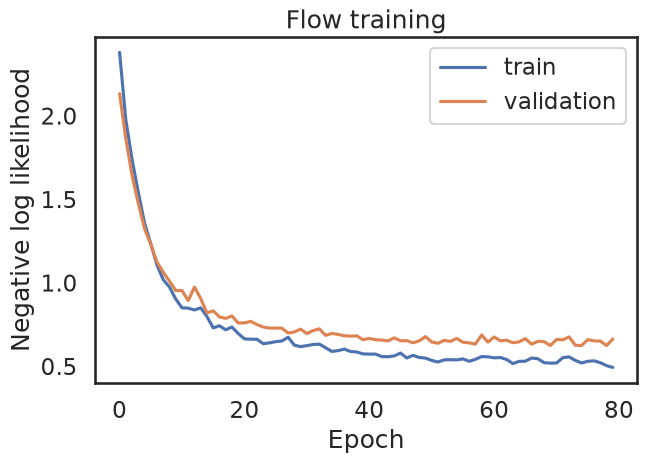

In [ ]:

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(losses["train"], label="train")
ax.plot(losses["val"], label="validation")
ax.set(title="Flow training", xlabel="Epoch", ylabel="Negative log likelihood")
ax.legend();


The training and validation curves should decrease together if the flow is fitting the dataset without obvious instability.
Now we can compare all three fitted densities on the same grid.


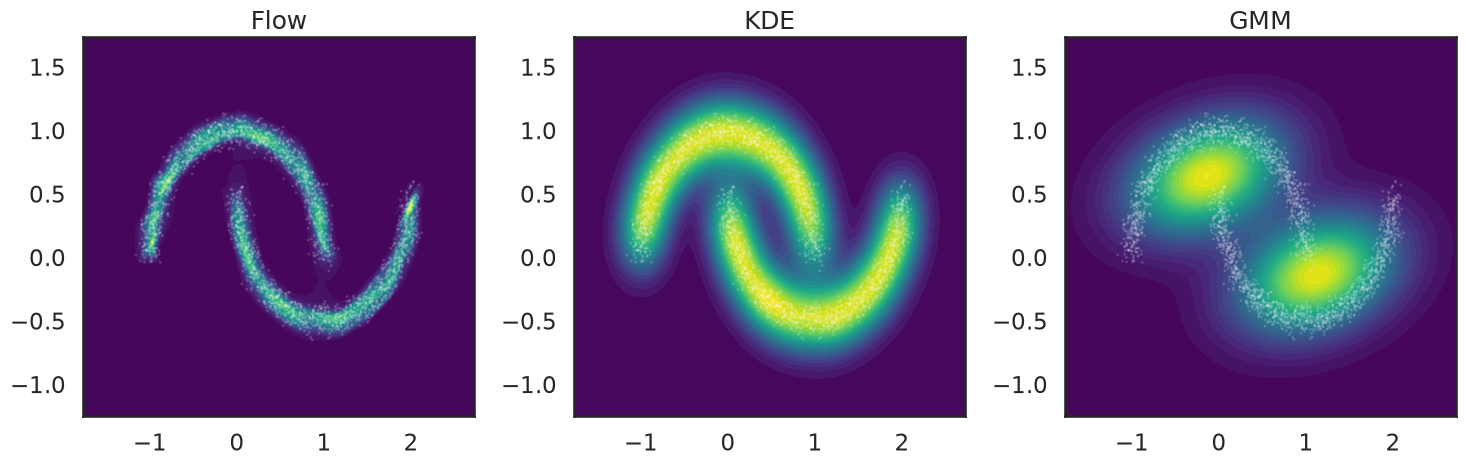

In [9]:

flow_log_density = np.asarray(flow.log_prob(jnp.asarray(grid)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, title in zip(axes, ["Flow", "KDE", "GMM"]): ax.set_title(title)
plot_density(axes[0], xs, ys, flow_log_density, data=X)
plot_density(axes[1], xs, ys, kde_log_density, data=X)
plot_density(axes[2], xs, ys, gmm_log_density, data=X)
fig.tight_layout()


The difference is structural.
A GMM approximates the moons by mixing Gaussians -- ellipses.
A flow starts from a simple base density and learns a nonlinear invertible warp of the metric space, so it can place probability mass along curved shapes while still remaining a normalized density model.

We can also sample from the estimated densities, and here, too, the flow model is much better. So it can also be used as a generative model.

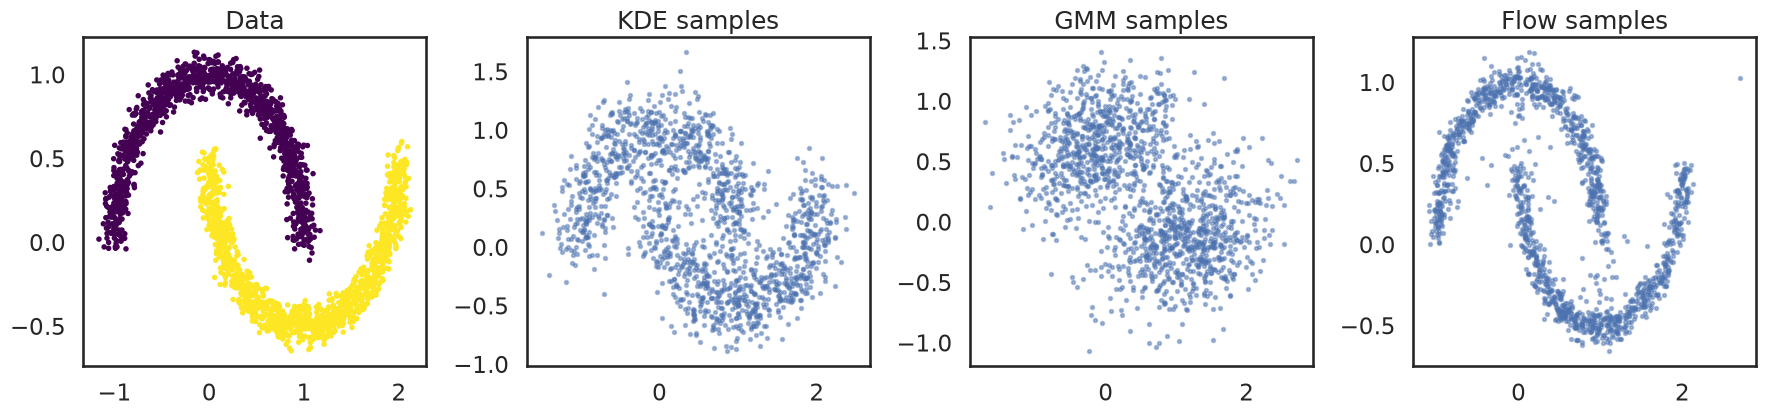

In [10]:

kde_samples = clip_to_window(kde.sample(1500, random_state=0), lower, upper)
gmm_samples, _ = gmm.sample(1500)
gmm_samples = clip_to_window(gmm_samples, lower, upper)

key, subkey = random.split(key)
flow_samples = np.asarray(flow.sample(subkey, (1500,)))
flow_samples = clip_to_window(flow_samples, lower, upper)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].scatter(X[:, 0], X[:, 1], c=labels, s=6, cmap="viridis")
axes[0].set(title="Data")

for ax, samples, title in zip(
    axes[1:],
    [kde_samples, gmm_samples, flow_samples],
    ["KDE samples", "GMM samples", "Flow samples"],
):
    ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.45)
    ax.set(title=title)
fig.tight_layout()


# A real dataset: UCI POWER

Two moons is a good place to build intuition and a bad place to draw conclusions.
In two dimensions KDE is *genuinely competitive* -- the first half of this notebook understates it, because with 2500 points on a plane, putting a small Gaussian on every point is close to optimal.

The case for flows is **dimension and sample size**:

- KDE is not really a fitted model. It stores the training set, so its memory and its scoring cost grow linearly with $n$, and in $d$ dimensions the number of points needed to fill space grows exponentially.
- A GMM is a fixed-size model, but every component is an ellipse, so matching a complicated shape means using a lot of components, and the number of components is a hyper-parameter.
- A flow is a fixed-size model with an *exact*, cheap likelihood and cheap sampling, and its cost at test time does not depend on how much data it was trained on.

To see that, we need a dataset that is neither two-dimensional nor small.

We use **POWER**, one of five benchmarks introduced by [Papamakarios, Pavlakou & Murray (2017)](https://arxiv.org/abs/1705.07057), the paper that defined MAF.
Every subsequent flow paper -- RealNVP comparisons, NAF, Block-NAF, Neural Spline Flows, FFJORD, Glow -- reports the same five numbers, so the published table gives us something to measure ourselves against.

POWER is derived from the UCI *Individual household electric power consumption* dataset: about two million minute-by-minute readings from one French household over four years, reduced to six dimensions.
Six dimensions is small enough that we can still look at every pairwise marginal, and large enough that KDE starts to hurt.

## Loading and preprocessing

We use Papamakarios's preprocessed archive (Zenodo record [1161203](https://zenodo.org/records/1161203), CC-BY-4.0), which is what the whole comparison literature uses. Fetch it once with

```
python download_data.py maf-benchmarks
```

The file has eight columns; the paper's Appendix D reduces them to six:

| # | column | kept? | why |
|---|---|---|---|
| 0 | global active power (kW) | ✔ | |
| 1 | global reactive power (kW) | ✘ | 23.5% of the values are exactly zero -- a discrete-valued attribute |
| 2 | voltage (V) | ✔ | |
| 3 | global intensity (A) | ✘ | Pearson $\rho = 0.999$ with global active power -- almost perfectly redundant |
| 4 | sub-metering 1 (Wh, kitchen) | ✔ | |
| 5 | sub-metering 2 (Wh, laundry) | ✔ | |
| 6 | sub-metering 3 (Wh, water heater and AC) | ✔ | |
| 7 | time of day (minutes past midnight) | ✔ | |

A near-perfectly correlated column is not just redundant: a continuous density on a set of measure zero is infinite, so a model that finds the relationship exactly gets an unbounded likelihood.
The same problem, in milder form, is why we have to *dequantize*.

In [5]:
def load_power(path='../data/maf/power/data.npy', seed=42):
    """UCI POWER, preprocessed as in Papamakarios et al. (2017), Appendix D."""
    rng = np.random.RandomState(seed)
    data = np.load(path)
    rng.shuffle(data)
    n = data.shape[0]

    # Drop global intensity (rho = 0.999 with active power) and then global
    # reactive power (23.5% exact zeros). Order matters: index 3 before index 1.
    data = np.delete(data, 3, axis=1)
    data = np.delete(data, 1, axis=1)

    # --- Dequantization. This is NOT optional. -------------------------------
    # The meters report rounded values: active power to 0.001 kW, voltage to
    # 0.01 V, and the three sub-meterings to whole watt-hours. A continuous
    # density fitted to values that only ever land on a lattice can pile up
    # arbitrarily tall spikes on that lattice, and the log-likelihood then runs
    # off to +infinity -- the model looks wonderful and has learned nothing.
    # Adding uniform noise of exactly one quantization step spreads each
    # reported value over the interval it actually stands for.
    # Time of day is already continuous in this file, so it gets no noise.
    data = data + np.hstack([
        0.001 * rng.rand(n, 1),   # global active power
        0.01 * rng.rand(n, 1),    # voltage
        rng.rand(n, 3),           # sub-metering 1, 2, 3
        np.zeros((n, 1)),         # time of day
    ])
    # -------------------------------------------------------------------------

    n_test = int(0.1 * n)                       # 10% test
    test, rest = data[-n_test:], data[:-n_test]
    n_val = int(0.1 * rest.shape[0])            # 10% of the rest for validation
    val, train = rest[-n_val:], rest[:-n_val]

    # Standardize using train + validation only.
    ref = np.vstack([train, val])
    mu, sd = ref.mean(axis=0), ref.std(axis=0)
    return (train - mu) / sd, (val - mu) / sd, (test - mu) / sd


POWER_COLUMNS = ['active power', 'voltage', 'sub-meter 1',
                 'sub-meter 2', 'sub-meter 3', 'time of day']

power_train, power_val, power_test = load_power()
print('train', power_train.shape, 'validation', power_val.shape, 'test', power_test.shape)

train (1659917, 6) validation (184435, 6) test (204928, 6)


Two million rows and six columns, split 1,659,917 / 184,435 / 204,928.

Let us look at the pairwise marginals. This is the six-dimensional version of the scatter plot we drew for the moons, and it is the last point at which we can *see* the distribution we are about to model.

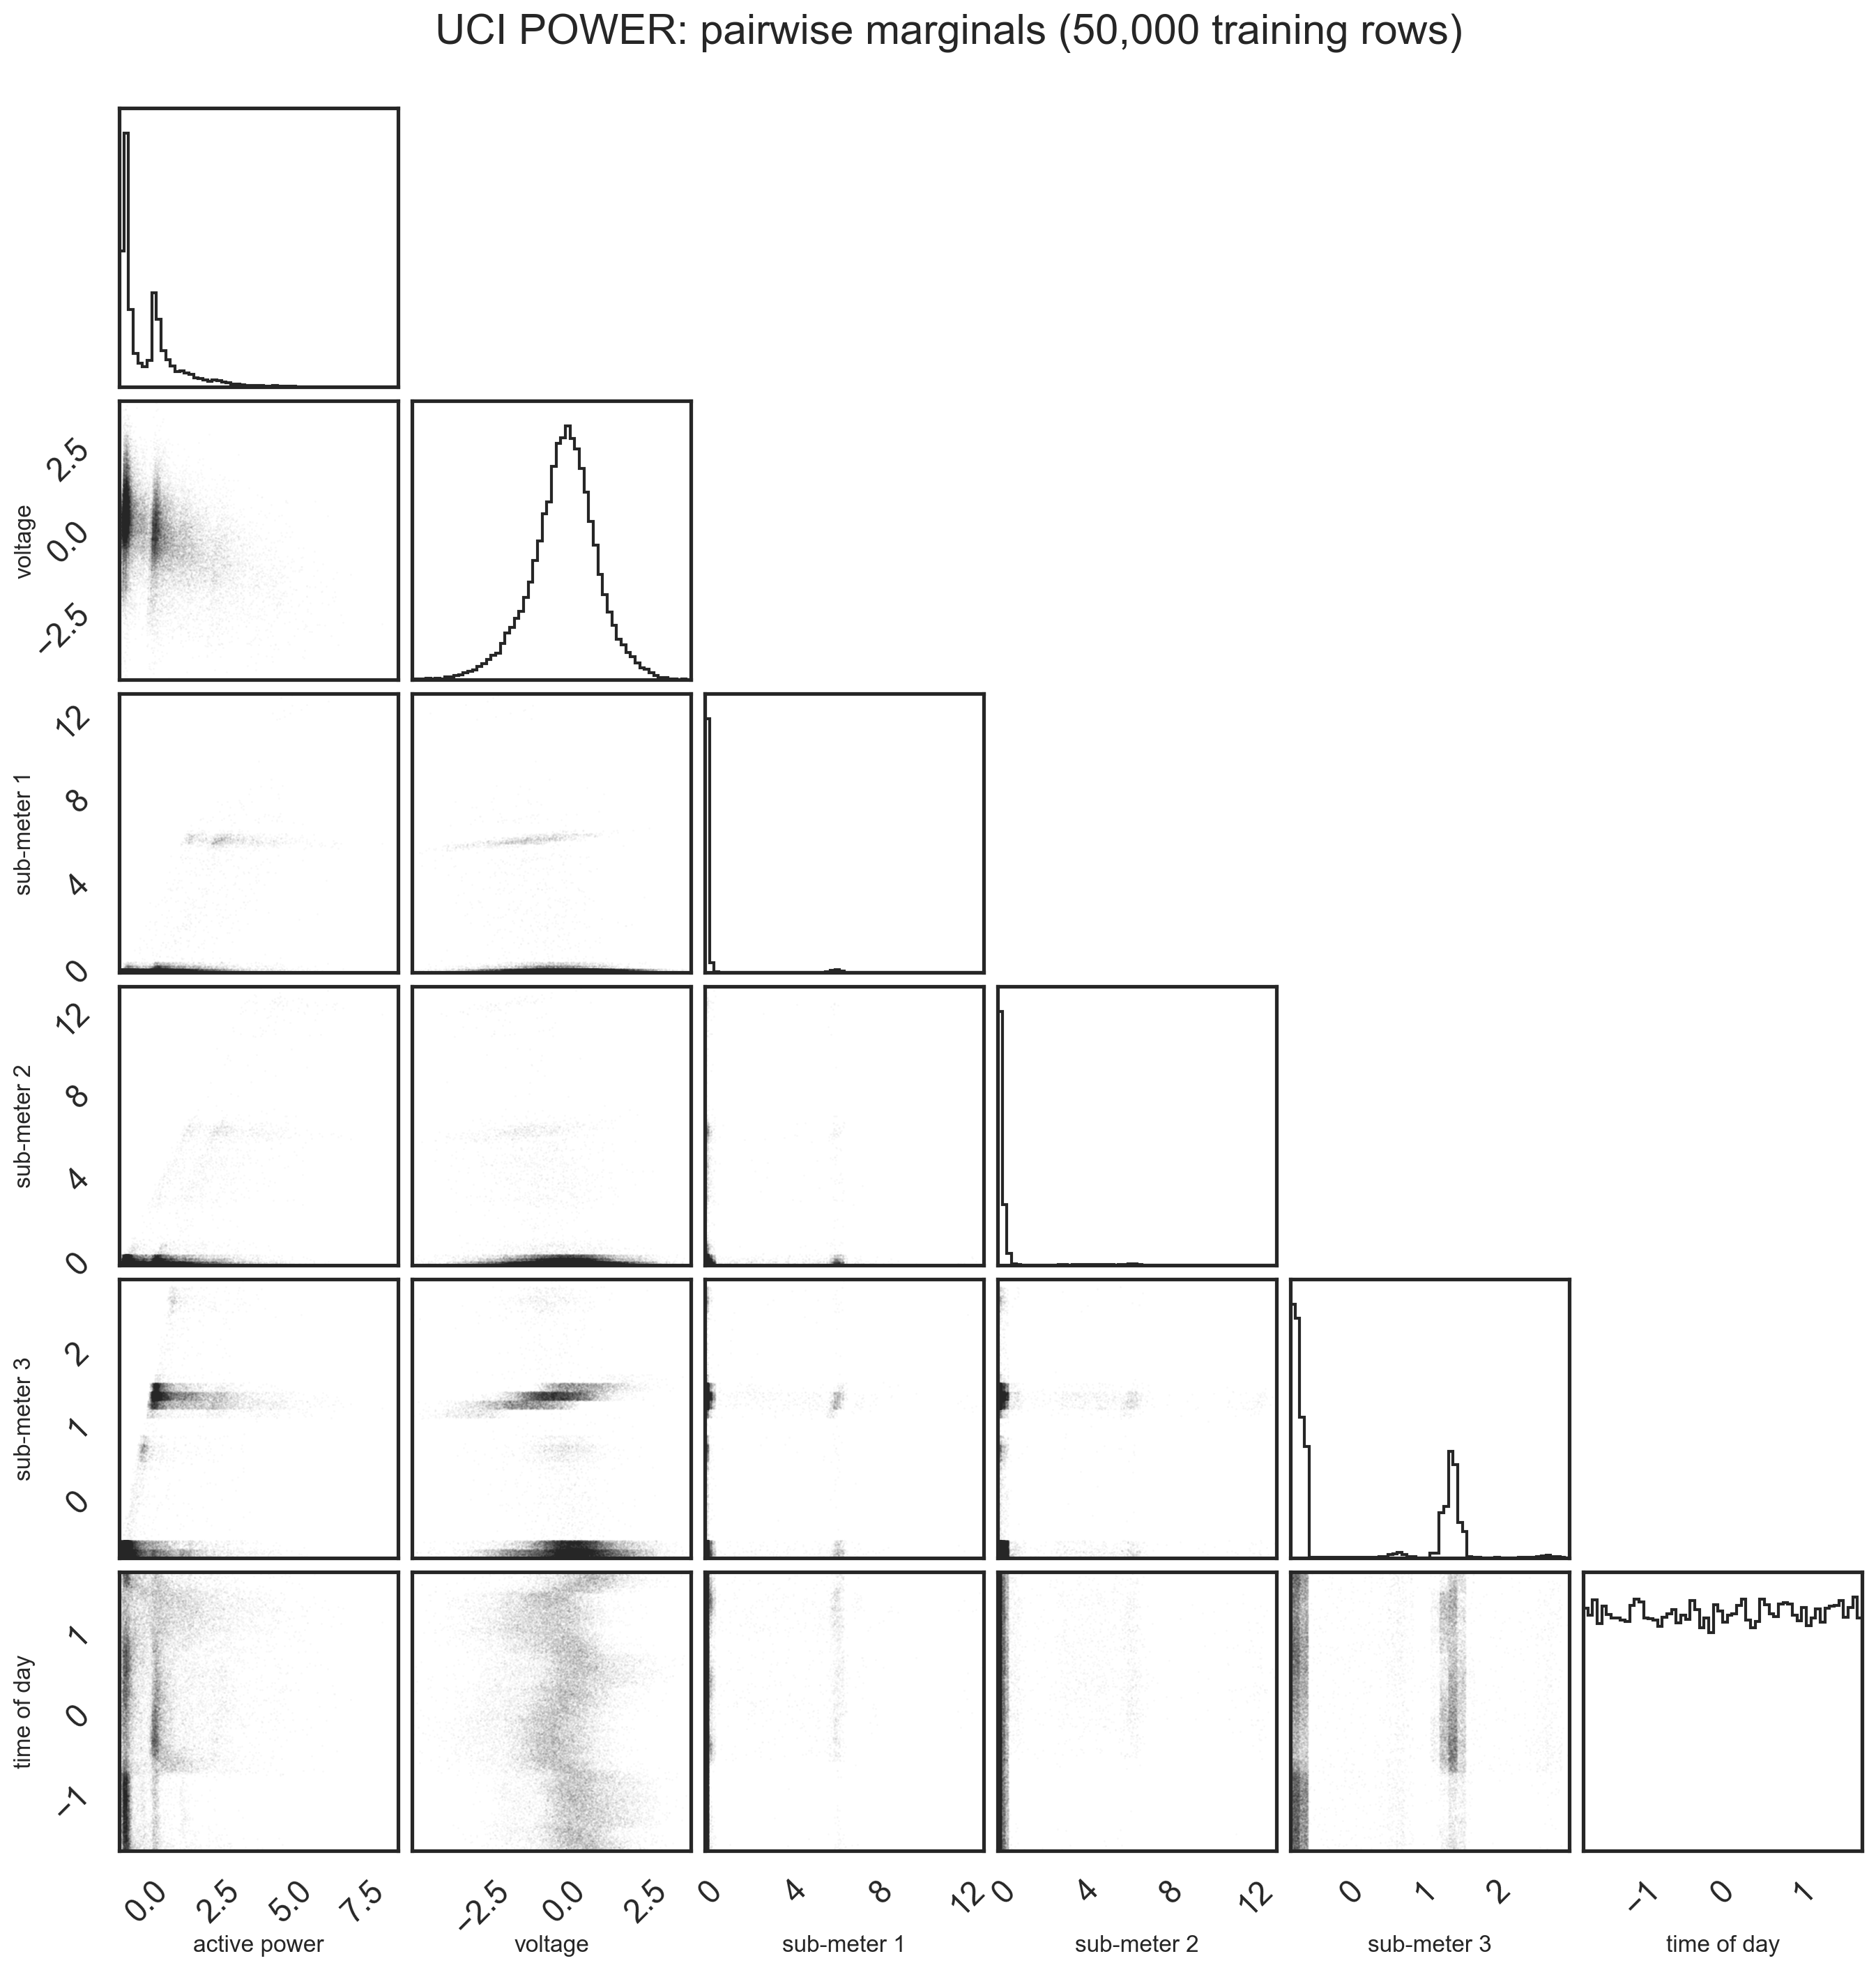

In [6]:
import corner

fig = corner.corner(
    power_train[:50_000],
    labels=POWER_COLUMNS,
    bins=60,
    max_n_ticks=4,
    plot_contours=False,
    plot_density=False,
    data_kwargs=dict(alpha=0.03, ms=1),
    label_kwargs=dict(fontsize=12),
)
fig.suptitle('UCI POWER: pairwise marginals (50,000 training rows)', y=1.02);

Nothing here is Gaussian.
The sub-meterings are spikes at zero with long thin tails -- most minutes, the kitchen is simply off.
Time of day is close to uniform by construction.
Active power is skewed and strongly coupled to time of day and to the sub-meterings.
A single Gaussian has no chance, and it is not obvious that a handful of ellipses will do much better.

## Subsampling, and why all four models see the same data

We fit every model on the same 200,000 training rows, a random subsample of the 1.66M available.

That is a deliberate handicap on the flow, which is happy with all 1.66M rows and trains on them in about four minutes on a GPU. 
The reason is comparability: KDE stores its training set and scores in $O(n_\text{train} \times n_\text{test})$, so at 1.66M rows it cannot be scored at all within a class. Giving all four models the same 200k rows keeps this an apples-to-apples comparison instead of a comparison of budgets.

We come back at the end to what the flow does when the handicap is removed.

In [13]:
N_TRAIN = 200_000

rng = np.random.default_rng(SEED)
X_train = power_train[rng.choice(power_train.shape[0], N_TRAIN, replace=False)].astype(np.float32)
X_validation = power_val[:20_000].astype(np.float32)
X_test = power_test.astype(np.float32)
print(X_train.shape, X_validation.shape, X_test.shape)

(200000, 6) (20000, 6) (204928, 6)


## Baseline 1: a single Gaussian

The MAF paper reports a full-covariance Gaussian as its own floor, so we can check our preprocessing against a published number before doing anything clever.

We report the **average test log-likelihood in nats per data point** (higher is better; nat=natural lograithm), summed over the six dimensions. Higher is better, and because the data is standardized rather than bounded, the numbers can be positive: a density can exceed 1.

In [14]:
def gaussian_log_likelihood(train, test):
    mean = train.mean(axis=0)
    cov = np.cov(train, rowvar=False)
    _, logdet = np.linalg.slogdet(cov)
    precision = np.linalg.inv(cov)
    delta = test - mean
    quadratic = np.einsum('ij,jk,ik->i', delta, precision, delta)
    return -0.5 * (quadratic + logdet + test.shape[1] * np.log(2 * np.pi))

t0 = time.time()
gaussian_ll = gaussian_log_likelihood(X_train, X_test).mean()
print(f'Gaussian: {gaussian_ll:.3f} nats  ({time.time() - t0:.1f}s)')

Gaussian: -7.742 nats  (0.0s)


−7.74 nats, which is exactly the figure in Table 2 of the MAF paper. The preprocessing is right.

## Baseline 2: Gaussian mixtures

A GMM is the natural next step: still ellipses, but several of them. How many do we need? We sweep the number of components and choose on the validation set.

In [15]:
gmm_results = {}
for n_components in (5, 10, 20, 50):
    t0 = time.time()
    gmm = GaussianMixture(n_components=n_components, covariance_type='full',
                          random_state=SEED, max_iter=200).fit(X_train)
    gmm_results[n_components] = dict(
        validation=gmm.score(X_validation), test=gmm.score(X_test),
        seconds=time.time() - t0, model=gmm)
    r = gmm_results[n_components]
    print(f'GMM {n_components:>3} components: '
          f'validation {r["validation"]:+.3f}  test {r["test"]:+.3f} nats  '
          f'({r["seconds"]:.0f}s)')

best_k = max(gmm_results, key=lambda k: gmm_results[k]['validation'])
gmm_ll = gmm_results[best_k]['test']
print(f'\nbest on validation: {best_k} components, {gmm_ll:+.3f} nats on test')

GMM   5 components: validation -1.188  test -1.200 nats  (3s)


GMM  10 components: validation -0.814  test -0.822 nats  (3s)


GMM  20 components: validation -0.381  test -0.391 nats  (11s)


GMM  50 components: validation -0.114  test -0.123 nats  (33s)

best on validation: 50 components, -0.123 nats on test


The mixture never stops improving -- and never stops getting more expensive, because a full covariance in six dimensions is 21 free parameters plus a mean plus a weight for every component.
We measured 100 components as well: **+0.014 nats, 94 seconds to fit**. Still climbing, still behind where the flow will land.

## Baseline 3: KDE, and the reason we have to cheat to score it

KDE has no fitting (`fit` just stores the array) so the whole cost is at scoring time, and it is $O(n_\text{train} \times n_\text{test})$.

Our test set has 204,928 points and our training set has 200,000. That is $4 \times 10^{10}$ kernel evaluations for one number, which will not finish inside a lesson.
**So we score KDE on a fixed random subsample of 5,000 test points and say so.**

Note which way that biases the comparison: it makes KDE look *cheaper* than it is, so the timing below is a lower bound on the real cost. The argument against KDE survives the concession.

In [16]:
N_KDE_TEST = 5_000
# Its own generator, so re-running this cell always scores the same points.
kde_test = X_test[np.random.default_rng(SEED + 1).choice(X_test.shape[0], N_KDE_TEST, replace=False)]

# Bandwidth swept over 0.05 ... 0.3 on a validation subsample. The optimum is
# flat between 0.07 and 0.09, so we use 0.08.
t0 = time.time()
power_kde = KernelDensity(kernel='gaussian', bandwidth=0.08).fit(X_train)
kde_fit_seconds = time.time() - t0

t0 = time.time()
kde_ll = power_kde.score_samples(kde_test).mean()
kde_score_seconds = time.time() - t0

print(f'KDE: {kde_ll:+.3f} nats on a {N_KDE_TEST}-point test subsample')
print(f'     fit {kde_fit_seconds:.1f}s + score {kde_score_seconds:.1f}s '
      f'= {kde_fit_seconds + kde_score_seconds:.1f}s')
print(f'     scoring the full {X_test.shape[0]:,} test points would take about '
      f'{kde_score_seconds * X_test.shape[0] / N_KDE_TEST / 60:.0f} minutes')

KDE: -0.783 nats on a 5000-point test subsample
     fit 0.2s + score 32.6s = 32.7s
     scoring the full 204,928 test points would take about 22 minutes


## The flow

Same model as the moons, three changes: six input dimensions instead of two, more layers and a wider network, and a wider spline interval because standardized POWER has values out past $\pm 8$.

Everything else -- the base distribution, the rational-quadratic spline transformer, `fit_to_data` -- is unchanged. That is the point: a flow is a *density model*, not a per-dataset construction.

In [17]:
key = random.key(SEED)

key, subkey = random.split(key)
power_flow = flowjax.flows.masked_autoregressive_flow(
    subkey,
    base_dist=flowjax.distributions.Normal(jnp.zeros(X_train.shape[1])),
    transformer=flowjax.bijections.RationalQuadraticSpline(knots=8, interval=5),
    flow_layers=8,
    nn_width=128,
    nn_depth=2,
)

Training is the same call as before (higher learning rate).
On the two moons it took a couple of seconds; here, on 200,000 six-dimensional rows, it takes under a minute on a GPU -- short enough to run live in class, so there is no checkpoint to reload.

In [18]:
t0 = time.time()
key, subkey = random.split(key)
power_flow, power_losses = flowjax.train.fit_to_data(
    subkey,
    power_flow,
    jnp.asarray(X_train),
    learning_rate=1e-3,
    batch_size=1024,
    max_patience=5,
    max_epochs=50,
    show_progress=True,
)
flow_train_seconds = time.time() - t0
print(f'\ntrained for {len(power_losses["train"])} epochs in {flow_train_seconds:.0f}s')


  0%|          | 0/50 [00:00<?, ?it/s]


  0%|          | 0/50 [00:07<?, ?it/s, train=1.3, val=0.506]


  2%|▏         | 1/50 [00:07<05:55,  7.26s/it, train=1.3, val=0.506]


  2%|▏         | 1/50 [00:07<05:55,  7.26s/it, train=0.509, val=0.279]


  4%|▍         | 2/50 [00:08<02:44,  3.42s/it, train=0.509, val=0.279]

...


 74%|███████▍  | 37/50 [00:34<00:09,  1.34it/s, train=-0.333, val=-0.339]


 74%|███████▍  | 37/50 [00:35<00:09,  1.34it/s, train=-0.357, val=-0.361]


 74%|███████▍  | 37/50 [00:35<00:09,  1.34it/s, train=-0.357, val=-0.361 (Max patience reached)]


 74%|███████▍  | 37/50 [00:35<00:12,  1.05it/s, train=-0.357, val=-0.361 (Max patience reached)]


trained for 38 epochs in 36s


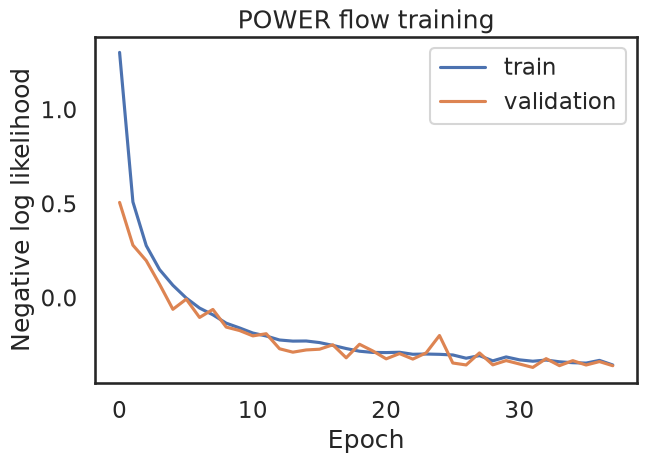

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(power_losses['train'], label='train')
ax.plot(power_losses['val'], label='validation')
ax.set(title='POWER flow training', xlabel='Epoch', ylabel='Negative log likelihood')
ax.legend();

`fit_to_data` holds out 10% of what we give it as its own validation split and stops when that stops improving, so the curve ends by itself rather than at `max_epochs`.

Now score the flow on the **full** test set -- which we can do, because unlike KDE its cost does not depend on the size of the training set.

In [20]:
t0 = time.time()
flow_ll = np.concatenate([
    np.asarray(power_flow.log_prob(jnp.asarray(X_test[i:i + 50_000])))
    for i in range(0, X_test.shape[0], 50_000)
]).mean()
flow_score_seconds = time.time() - t0
print(f'Flow: {flow_ll:+.3f} nats on all {X_test.shape[0]:,} test points '
      f'({flow_score_seconds:.1f}s)')

Flow: +0.350 nats on all 204,928 test points (7.7s)


Eight seconds for 204,928 points, against KDE's estimated 22 minutes for the same job.

All four models, side by side:

In [21]:
print(f'{"model":<28}{"test log-likelihood":>22}   scored on')
print('-' * 72)
for name, ll, n in [
    ('Gaussian', gaussian_ll, X_test.shape[0]),
    (f'GMM ({best_k} components)', gmm_ll, X_test.shape[0]),
    ('KDE (bandwidth 0.08)', kde_ll, N_KDE_TEST),
    ('Masked autoregressive flow', flow_ll, X_test.shape[0]),
]:
    print(f'{name:<28}{ll:>+15.3f} nats   {n:,} points')

model                          test log-likelihood   scored on
------------------------------------------------------------------------
Gaussian                             -7.742 nats   204,928 points
GMM (50 components)                  -0.123 nats   204,928 points
KDE (bandwidth 0.08)                 -0.783 nats   5,000 points
Masked autoregressive flow           +0.350 nats   204,928 points


## Do the samples look like the data?

A log-likelihood is one number. The other half of what a flow gives us is sampling, so we can draw from the fitted model and put its marginals next to the data's.

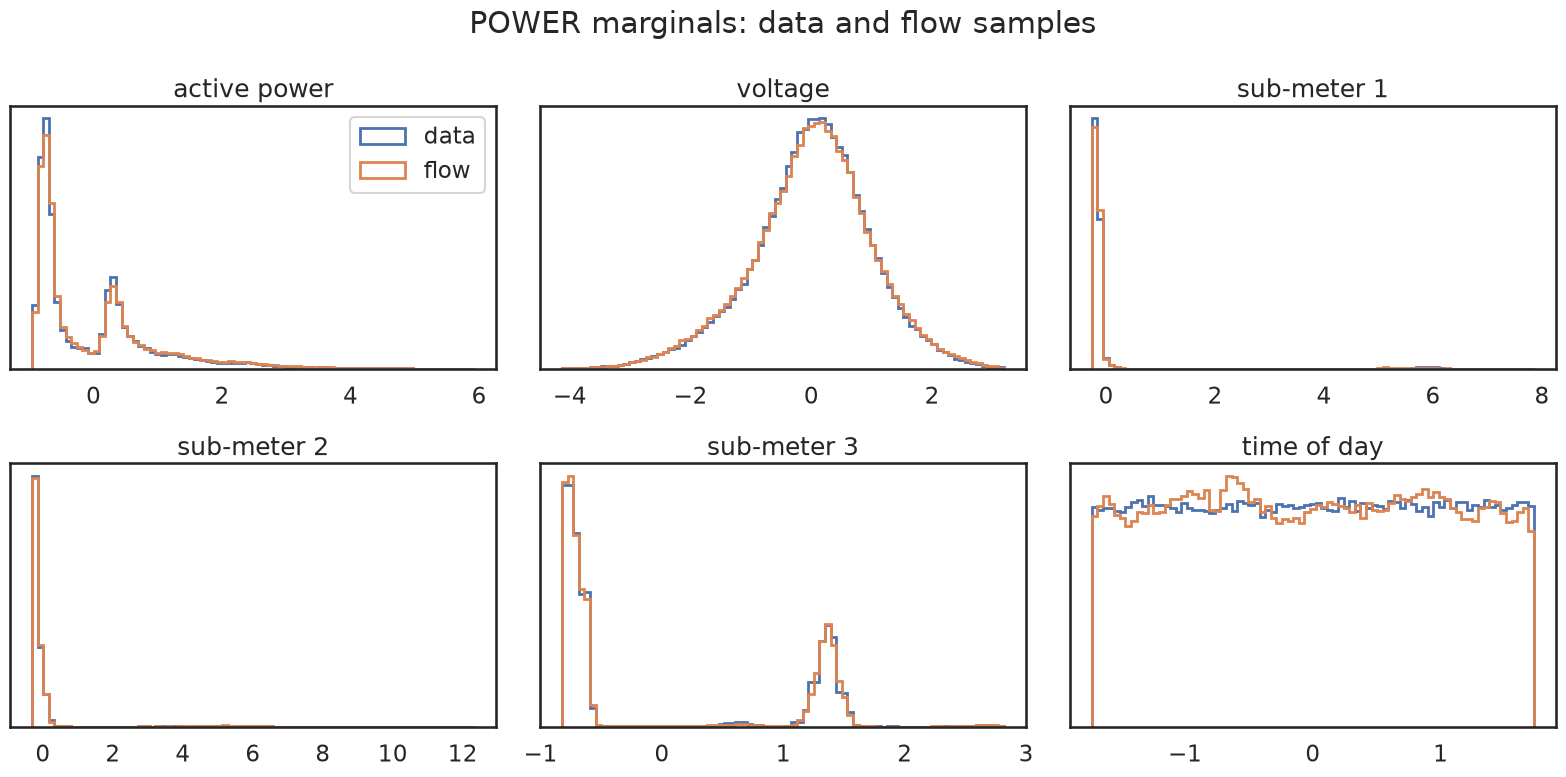

In [22]:
key, subkey = random.split(key)
power_samples = np.asarray(power_flow.sample(subkey, (200_000,)))

# 1D marginals: data against flow samples, one panel per dimension
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, j, name in zip(axes.ravel(), range(6), POWER_COLUMNS):
    lo, hi = np.percentile(X_train[:, j], [0.05, 99.95])
    bins = np.linspace(lo, hi, 80)
    ax.hist(X_train[:, j], bins=bins, density=True, histtype='step', lw=2, label='data')
    ax.hist(power_samples[:, j], bins=bins, density=True, histtype='step', lw=2, label='flow')
    ax.set(title=name, yticks=[])
axes[0, 0].legend()
fig.suptitle('POWER marginals: data and flow samples')
fig.tight_layout()

Every marginal lines up, including the spike-at-zero sub-meterings that no Gaussian mixture would get right.

But matching all six marginals is necessary, not sufficient -- a model that got the dependence structure completely wrong could still do that. So we also compare a joint: active power against time of day, the most structured panel in the corner plot above.

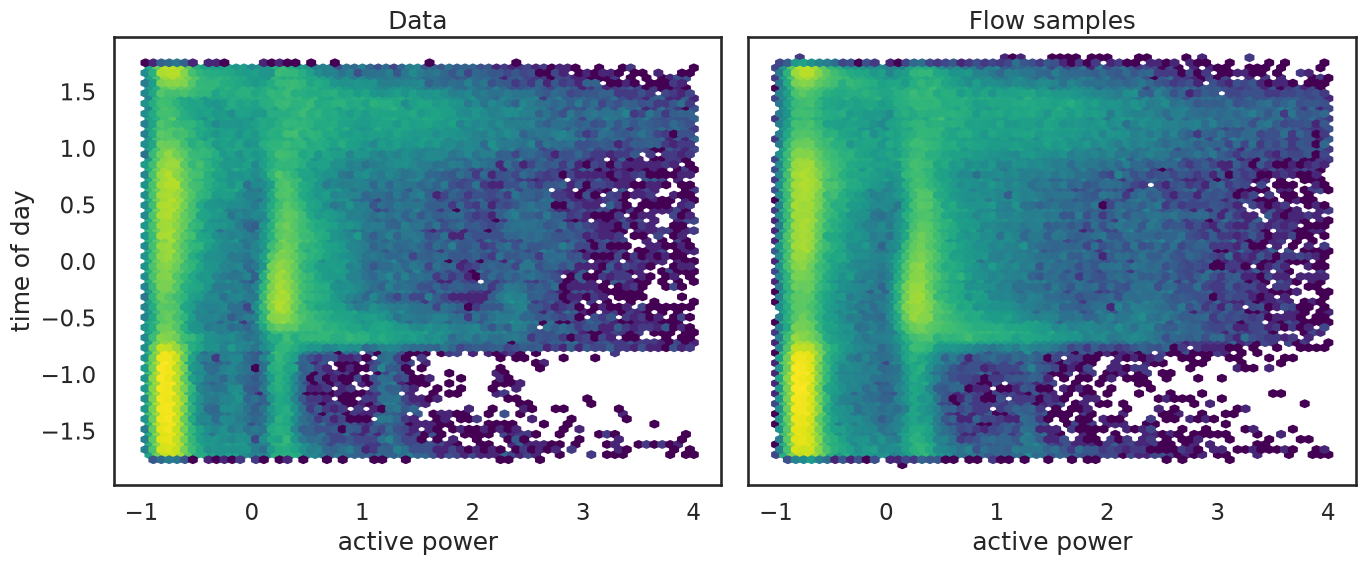

In [23]:
# The marginals can match while the joint structure does not, so look at a pair.
# Active power against time of day is the most structured panel in the corner plot.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, data, title in zip(axes, [X_train, power_samples], ['Data', 'Flow samples']):
    ax.hexbin(data[:, 0], data[:, 5], gridsize=70, bins='log',
              extent=(-1, 4, -1.8, 1.8), cmap='viridis')
    ax.set(title=title, xlabel=POWER_COLUMNS[0])
axes[0].set_ylabel(POWER_COLUMNS[5])
fig.tight_layout()

## What the numbers mean

Our four numbers are in the table above. Published numbers on POWER, for the same preprocessing and the *full* training set:

| model | reported |
|---|---|
| RealNVP (10 layers) | 0.17 ± 0.01 |
| MAF (10 layers) | 0.24 ± 0.01 |
| NAF | 0.62 ± 0.01 |

**Our number is not the same experiment as the published 0.24**, in either direction. We used a 200,000-row subsample rather than 1.66M rows, no hyperparameter search, and eight layers rather than ten -- all of which should hurt. But our transformation is a *rational-quadratic spline* ([Durkan et al. 2019](https://arxiv.org/abs/1906.04032)), which came two years after the MAF paper and is strictly more expressive than the affine transformation MAF used. That is the honest reading of the gap: we are not reproducing MAF, we are running a later and better model with less data and less tuning, and it lands between MAF and NAF.

Expect your own run to differ in the second decimal. Two consecutive runs of this notebook on the same GPU reproduced 38 epochs and +0.350 exactly, but GPU reductions are not bit-deterministic across hardware and driver versions, and a slightly different trajectory makes early stopping fire at a different epoch -- a variant of this code stopped at 46 epochs and scored +0.368. That spread is far smaller than any of the differences we are drawing conclusions from, but it is worth knowing before you chase a hundredth of a nat.

**Removing the handicap helps, and it is cheap.** We trained the identical flow on all 1,659,917 training rows: **0.477 nats in 244 seconds**. So roughly another 0.13 nats is sitting in the subsample we imposed for KDE's benefit. KDE cannot take that trade -- we measured its fit-and-score time on 5,000 test points as 4.9 s, 9.2 s, 16.9 s and 33.0 s for 25k, 50k, 100k and 200k training rows, which is exactly the linear growth the $O(n_\text{train} \times n_\text{test})$ cost predicts. At 1.66M rows it would take about four and a half minutes to score 5,000 points, and about three hours to score the test set the flow scores in eight seconds.

**Ordering matters more than the exact values.** The Gaussian is 7.4 nats behind everything else; that is the cost of assuming one ellipse. KDE, which was competitive on the moons, is now *worse than a 20-component GMM* -- in six dimensions its local kernels no longer have enough neighbours to average over. And the flow beats a 100-component GMM while being a fixed-size model you can sample from in one pass.

Across the five MAF benchmarks the original paper found MAF best on three and MADE MoG best on the other two, so no single density model wins everywhere. What generalizes is the shape of the argument: as $d$ and $n$ grow, models that *store* data lose to models that *compress* it into a map.

### Where the three model families sit

- An **autoencoder** learns a representation. It has no density and cannot tell you how probable a point is -- it is not a generative model.
- A **normalizing flow** learns a density you can both evaluate exactly and sample from, at the price of invertibility, which constrains the architecture.
- A **GAN** learns to sample without ever writing down a density.

Normalizing flows also have a second classical use we do not demonstrate here: [Rezende & Mohamed (2015)](https://arxiv.org/abs/1505.05770) named them and used them to make variational posteriors more flexible in variational inference.

## Exercises

**On the two moons**

1. Change `flow_layers`, `nn_width`, or the number of spline `knots` and compare the samples and the density. Which of the three buys you the most?
2. Increase or decrease the KDE bandwidth and compare the density heatmap. How wrong does it have to be before the moons stop being visible?

**On POWER**

3. **Drop the dequantization noise.** Comment out the `data + np.hstack([...])` step in `load_power` and refit the flow. Watch the training log-likelihood climb past anything the model deserves, and explain in one sentence what the flow is actually doing to the discrete sub-metering values. This is the single most important failure mode in this notebook.
4. **Measure the crossover.** Plot KDE's fit-and-score time and the flow's train-and-score time against training-set size, for 25k, 50k, 100k and 200k rows, holding the test set fixed at 5,000 points. One of the two curves is linear in $n_\text{train}$ and the other is roughly flat. Where would they cross if you extrapolated to the full 1.66M rows?

**On a harder dataset**

5. **MINIBOONE.** `data/maf/miniboone/data.npy` is 36,488 rows in 43 dimensions -- the smallest of the five MAF benchmarks and the highest-dimensional one we downloaded. Split and standardize it the same way, then fit the Gaussian, a GMM and the flow. (Skip KDE, or score it on a few hundred points.) The published MAF(5) number is 11.75 nats against a Gaussian baseline of −37.24. This is where the classical baselines stop being competitive at all -- with 43 dimensions and 30,000 rows there is simply nothing local for a kernel to average over.

# References

1. Papamakarios, Pavlakou & Murray (2017), [*Masked Autoregressive Flow for Density Estimation*](https://arxiv.org/abs/1705.07057), NeurIPS. Introduced the MAF and the five benchmark datasets; Table 2 is the source of the POWER numbers quoted above.
2. Durkan, Bekasov, Murray & Papamakarios (2019), [*Neural Spline Flows*](https://arxiv.org/abs/1906.04032), NeurIPS. The rational-quadratic spline transformer this notebook uses.
3. Papamakarios, Nalisnick, Rezende, Mohamed & Lakshminarayanan (2021), [*Normalizing Flows for Probabilistic Modeling and Inference*](https://jmlr.org/papers/v22/19-1028.html), JMLR 22(57). The review to read next.
4. Rezende & Mohamed (2015), [*Variational Inference with Normalizing Flows*](https://arxiv.org/abs/1505.05770), ICML. Named normalizing flows, and used them for variational inference rather than density estimation.
5. [FlowJAX documentation](https://danielward27.github.io/flowjax/) and [Equinox](https://github.com/patrick-kidger/equinox/).
6. Kevin P. Murphy, *Probabilistic Machine Learning: An Introduction*, chapter 23.
7. The POWER and MINIBOONE data are Papamakarios's preprocessed archive, [Zenodo record 1161203](https://zenodo.org/records/1161203) (CC-BY-4.0); POWER derives from the UCI [Individual household electric power consumption](https://archive.ics.uci.edu/dataset/235/) dataset.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)